# Dataset Preparation

This project uses dataset the [text8](https://www.kaggle.com/datasets/yorkyong/text8-zip), which is a large cleaned corpus of English text extracted from Wikipedia.
The dataset was chosen because it covers a wide range of topics rather than focusing on a single domain, making it suitable for training general-purpose Word2Vec embeddings. Compared to the AG News dataset used previously, text8 is more diverse and not limited to specific categories.

In [2]:
with open('data/text8') as f:
    text = f.read()

print(text[:100])

 anarchism originated as a term of abuse first used against early working class radicals including t


**Tokenization and vocabulary construction.**

The dataset consists of a single long sequence of text. This text is tokenized, and token frequencies are computed to build a vocabulary that reflects how often each word appears in the corpus.

In [3]:
from src.core.preprocessing import tokenization
from typing import Counter

word_counts = Counter()
len_tokens = 0

len_tokens += len(tokenization(text=text, word_counts=word_counts))

In [4]:
len_tokens

17005207

In [5]:
len(word_counts.keys())

253854

In [6]:
word_counts.most_common(15)

[('the', 1061396),
 ('of', 593677),
 ('and', 416629),
 ('one', 411764),
 ('in', 372201),
 ('a', 325873),
 ('to', 316376),
 ('zero', 264975),
 ('nine', 250430),
 ('two', 192644),
 ('is', 183153),
 ('as', 131815),
 ('eight', 125285),
 ('for', 118445),
 ('s', 116710)]

**Rare word filtering.**

Words that appear only a few times in the corpus are removed, as such tokens are often noisy (e.g., typos or dataset-specific artifacts) and provide limited value for learning reliable word embeddings.
This filtering step helps reduce vocabulary size and improves the stability of the training process.

In [7]:
unique_words = [w for w, c in word_counts.items() if c > 5]

In [8]:
len(unique_words)

63641

In [9]:
word_counts = Counter({w: c for w, c in word_counts.items() if w in unique_words})

In [ ]:
word2id = {}
id2word = {}

for idx, word in enumerate(unique_words):
    word2id[word] = idx
    id2word[idx] = word

In [12]:
len(word_counts) == len(unique_words)

True

In [13]:
id_counts = Counter({word2id[w]: c for w, c in word_counts.items()})
total_tokens = sum(word_counts.values())

Subsampling is a technique reduce the dominance of very frequent words (such as the, of, and) during training. Each word is randomly discarded with probability P, meaning that the more frequent a word is in the corpus, the more likely it is to be removed. This helps the model focus on more informative words and speeds up training.

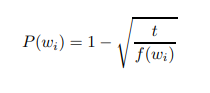

In [12]:
from src.core.preprocessing import encode_text

In [13]:
from src.core.dataset import build_skipgram_pairs

skipgram_pairs = []
context_window = 2

tokens = encode_text(text=text, word2id=word2id)
pairs = build_skipgram_pairs(tokens, context_window, id_counts, total_tokens, tolerance=1e-5)
skipgram_pairs.extend(pairs)

Tokens length before subsampling:  16680599
Tokens length after subsampling:  4626547


In [15]:
len(skipgram_pairs)

18508602

In [14]:
# update word_counts
# because some words were deleted

word_counts = Counter({w: c for w, c in word_counts.items() if w in unique_words})

In [15]:
len(word_counts) == len(unique_words)

True

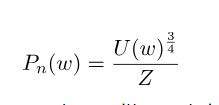

**Negative sampling distribution.**

The negative sampling distribution is defined as the unigram word frequency raised to the power of 0.75 and normalized by a constant
Z.
The function build_unigram_probs implements this formulation by computing the normalized probability distribution used to sample negative words during training.

In [16]:
import numpy as np


def build_unigram_probs(counts: np.ndarray, power: float = 0.75) -> np.ndarray:
    probs = counts**power
    Z = probs.sum()
    probs /= Z
    return probs

In [17]:
word_counts_array = np.zeros(len(unique_words))

In [18]:
for i in range(len(word_counts_array)):
    current_word = id2word[i]
    freq = word_counts[current_word]
    word_counts_array[i] = freq

In [19]:
probs = build_unigram_probs(word_counts_array)

In [20]:
rng = np.random.default_rng(42)

In [21]:
print(len(id2word))

63641


# Gradient Checker


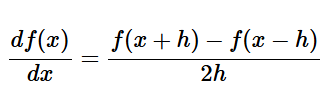
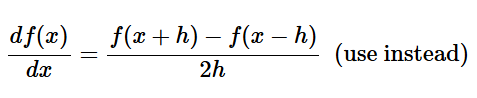

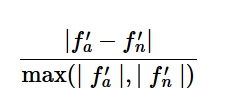

In [20]:
from tests.test_gradients import test_gradients

test_gradients()

# Training

To train the Skip-Gram with Negative Sampling model, the loss function shown above is optimized.
The text is processed using a sliding context window to form positive (center, context) pairs, while negative samples are selected dynamically during training via negative sampling.


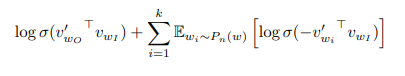

In [23]:
from src.core.skip_gram_negative_sampling import *

model = Word2VecSGNS(
    vocab_size=len(unique_words), dim=100, word2id=word2id, id2word=id2word, optimizer="adam"
)

In [24]:
model.load("outputs/model/epoch_2_part_1.00_loss_2.2405.npz")

In [25]:
from src.core.training import *
train(
    model=model,
    data=skipgram_pairs,
    num_epochs=1,
    k=5,
    batch_size=512,
    probs=probs,
    rng=rng,
    print_every=10000
)

  0%|          | 0/1 [00:00<?, ?it/s]

Epoch: 1

Epoch part 0.28: loss=2.2341
Epoch part 0.55: loss=2.2495
Epoch part 0.83: loss=2.2591
epoch 1: loss=2.2636


100%|██████████| 1/1 [5:16:47<00:00, 19007.58s/it]


# Evaluation

For evaluation, a similarity function is used to retrieve the most similar word vectors by computing cosine similarity between embeddings.
Given a query word, the function returns the top-𝑁 closest words in the embedding space.

In [10]:
from src.core.skip_gram_negative_sampling import *

model = Word2VecSGNS(
    vocab_size=0, dim=100, word2id={}, id2word={}, optimizer="adam"
)

model.load("outputs/model/epoch_2_part_1.00_loss_2.2405.npz")

In [11]:
len(model.word2id)

63641

In [12]:
from src.evaluation.intrinsic_evaluation.get_top_n_similar_words import get_top_n_similar_words

get_top_n_similar_words(
    model, "olympic", model.word2id, model.id2word, n=10, use_central=True
)

[('olympics', 0.6664973196962887),
 ('medallist', 0.5961720429181518),
 ('medalist', 0.5692393686509161),
 ('saddledome', 0.5546106696613493),
 ('basketball', 0.5326939548028022),
 ('competitions', 0.5321164395877513),
 ('championships', 0.5254275772492929),
 ('medalists', 0.5163728903169719),
 ('sportsmen', 0.4945868079785664),
 ('dortmund', 0.49019473262826524)]

In [13]:
get_top_n_similar_words(
    model, "alps", model.word2id, model.id2word, n=10, use_central=True
)

[('alpine', 0.5819849778586719),
 ('hilly', 0.5747584403551023),
 ('aosta', 0.5563054398643121),
 ('weser', 0.5541282431995329),
 ('lowlands', 0.535440010584425),
 ('christianised', 0.5205977259688607),
 ('mountains', 0.5186958685266969),
 ('danube', 0.5173257314126676),
 ('pyrenees', 0.5161344297978069),
 ('carniola', 0.512914257059309)]

In [14]:
get_top_n_similar_words(
    model, "spain", model.word2id, model.id2word, n=10, use_central=False
)

[('portugal', 0.8092157781924688),
 ('minorca', 0.7827639417657734),
 ('spanish', 0.7771285080414905),
 ('ildefonso', 0.7648592428007395),
 ('llar', 0.760492161936819),
 ('majorca', 0.7525255325847311),
 ('history', 0.7504141058568359),
 ('italy', 0.7489184634205629),
 ('viceroyalty', 0.7450510632317513),
 ('cordiale', 0.739986977603071)]

In [15]:
from src.evaluation.intrinsic_evaluation.plot_top_words_map import plot_top_words_map

plot_top_words_map(model, 200, word_counts)

In [16]:
from src.evaluation.intrinsic_evaluation.plot_example_cluster import plot_example_cluster

plot_example_cluster(model)

Shape: (35, 100)


In [17]:
from src.evaluation.intrinsic_evaluation.plot_capital_relationships import plot_capital_relationships

plot_capital_relationships(model)

In [18]:
from src.evaluation.intrinsic_evaluation.plot_comparative_relations import plot_comparative_relations

plot_comparative_relations(model)

In [19]:
from src.evaluation.intrinsic_evaluation.plot_plural_relations import plot_plural_relations

plot_plural_relations(model)